Baryonic halo model
===================

This notebook explores the **[Fedeli (2014)](https://arxiv.org/abs/1401.2997)** baryonic halo model at the
*ingredient level*.
Unlike the high-level baryonic modules—which return only the final total matter power spectrum or an effective boost—here we expose and manipulate the **physical building blocks** of the model.

The Fedeli model is a semi-analytic extension of the halo model in which **dark matter, hot gas, and stars are treated as separate components**, each with its own mass fraction and density profile inside halos. The total matter power spectrum is then assembled from the auto- and cross-spectra of these components.

### What this notebook does

We step through the model in the same logical order as the theory:

1. **Mass fractions**

   Specify how the halo mass is split between dark matter, hot gas, and stars as a function of halo mass (and implicitly redshift).


2. **Density profiles**

   Define the spatial distribution of each component inside halos:

   * Dark matter: NFW-like profiles,
   * Gas: cored profiles motivated by X-ray observations,
   * Stars: compact profiles tracing the stellar component.


3. **Power spectra and terms**

   Construct the individual **1-halo and 2-halo contributions**, including all **auto- and cross-terms**, and inspect how each component contributes to the total matter power spectrum across scales.


4. **One-parameter sensitivity**

    In addition, we perform controlled one-parameter sweeps around a
    fiducial configuration, varying individual baryonic parameters while
    holding the rest of the halo-model setu fixed. This allows us to isolate
     the impact of each physical ingredient on the matter power spectrum and
      to build intuition for which parameters drive suppression or enhancement on different scales.


### Why this level of access matters

This low-level interface is designed for **model exploration and experimentation**:

* testing alternative mass-fraction parameterizations,
* modifying profile shapes or concentrations,
* isolating specific halo-model terms,
* understanding which physical assumptions drive power suppression or enhancement at a given scale.

All intermediate quantities (fractions, profiles, Fourier transforms, individual power-spectrum terms) are directly accessible, making this notebook a sandbox for developing, validating, and extending baryonic prescriptions beyond simple effective boosts.



# Setup: cosmology and halo-model grids

We start by defining the cosmology and the halo-model ingredients used throughout the notebook:
a mass definition ($M_{200\mathrm{m}}$), a halo mass function, and the $(M, k)$ grids on which we evaluate
mass fractions, density profiles, and power-spectrum terms. All masses here are in $\mathrm{M_\odot}/h$ and
$k$ is sampled over a wide range to cover both 2-halo (large-scale) and 1-halo (small-scale) regimes.

Notice that we are calling the `baryon_halo_model` class directly, and not
the usual front-end `BaryonsFedeli14` module from `pyCCL`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyccl as ccl
from pyccl.baryons.fedeli14_bhm.baryon_halo_model import BaryonHaloModel
from pyccl.baryons.fedeli14_bhm.examples.plot_style import (
    plot_style,
    get_colors,
)

In [2]:
# basic cosmology ingredients
cosmo = ccl.CosmologyVanillaLCDM()  # cosmology object
k_grid = np.logspace(-3, 2, 256)  # wavenumber k
scale_factor = 1.0  # scale factor a
h = cosmo["h"]  # dimensionless hubble parameter

# halo-model ingredients
mass_def = ccl.halos.MassDef(200, "matter")  # mass definition
hmf = ccl.halos.MassFuncTinker08(mass_def=mass_def, mass_def_strict=False)  # halo mass function
mass_grid = np.logspace(10, 16, 400)  # mass grid; in Msun/h

# here we initialize the baryonic halo model
bhm = BaryonHaloModel(
    cosmo=cosmo,
    mass_def=mass_def,
    mass_function=hmf,
    concentration=None
)


# Mass fractions as a function of halo mass

Here we evaluate the **mass fractions** of the three matter components inside halos:
dark matter $f^{\rm DM}(M)$, hot gas $f^{\rm G}(M)$, and stars $f^S(M)$,
 at the chosen scale factor
(here $a=1$, i.e. $z=0$). These functions encode how the model partitions the **equivalent halo mass**
among components before any spatial information (profiles) enters.

We plot $\log_{10} f_i(M)$ versus $\log_{10} M$ across the full halo-mass range used in the notebook.
A small floor (`eps`) is applied to avoid taking $\log_{10}(0)$ when a component becomes negligible at
some masses.

For reference, the gray horizontal line marks the **universal baryon fraction**
 $\Omega_b/\Omega_m$,
which the gas fraction approaches at high masses by construction in the Fedeli-style parameterization.

This plot corresponds to Fig. 1 of Fedeli (2014).


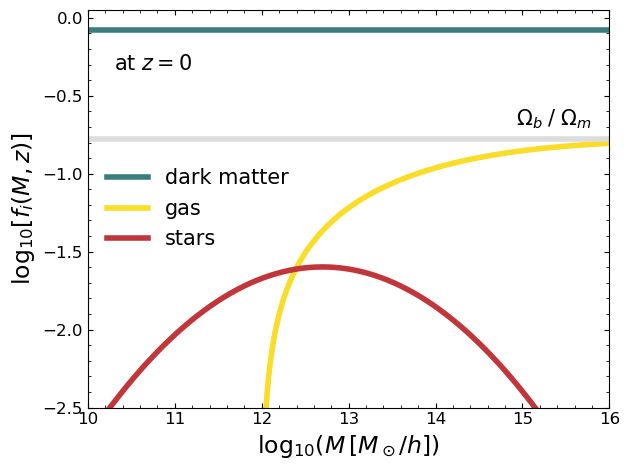

In [3]:
# We extract the mass fractions from the baryonic halo model
# for the setup we defined above
frac_gas, frac_star, frac_dm = bhm.mass_fractions(a=scale_factor)

# avoid log10(0) screaming at you
eps = 1e-40
f_gas = np.maximum(frac_gas(mass_grid), eps)
f_star = np.maximum(frac_star(mass_grid), eps)
f_dm = np.maximum(frac_dm(mass_grid), eps)

baryon_fraction = cosmo["Omega_b"] / cosmo["Omega_m"]

with plot_style():
    fig, ax = plt.subplots()

    cols = get_colors(3)
    ax.plot(np.log10(mass_grid), np.log10(f_dm), label="dark matter", color=cols[0])
    ax.plot(np.log10(mass_grid), np.log10(f_gas), label="gas", color=cols[1])
    ax.plot(np.log10(mass_grid), np.log10(f_star), label="stars", color=cols[2])

    ax.set_xlabel(r"$\log_{10}\!\left(M\,[M_\odot/h]\right)$")
    ax.set_ylabel(r"$\log_{10}\!\left[f_i(M,z)\right]$")
    ax.set_xlim(10, 16)
    ax.set_ylim(-2.5, 0.05)
    ax.legend(frameon=False, loc="best")

    # annotate at which redshift (a=1) we evaluate the model
    ax.text(0.05, 0.85, r"at $z=0$", transform=ax.transAxes, fontsize=15)

    # horizontal line at log10(baryon_fraction)
    ax.axhline(np.log10(baryon_fraction), c="gainsboro")
    ax.text(
        0.82,
        -0.65,
        r"$\Omega_b \; / \; \Omega_m$",
        transform=ax.get_yaxis_transform(),
        ha="left",
        va="center",
        fontsize=15
    )

    # optionally save the figure
    # plt.savefig("mass_fractions.pdf", bbox_inches="tight", dpi=300)

    plt.show()


# Component density profiles in Fourier space

Next we inspect the **normalized Fourier-space halo profiles** for each component,
$U_X(k\,|\,M)/M$, where $X\in\{\mathrm{DM},\,\mathrm{G},\,\mathrm{S}\}$
denotes dark matter, gas, and stars, respectively.
These profiles are the Fourier transforms of the real-space density profiles and determine how each
component contributes to the 1-halo and 2-halo terms once convolved with the halo mass function and bias.

We evaluate the profiles at $z=0$ for two representative halo masses ($10^{13}$ and $10^{14}\,M_\odot/h$).
Following the presentation in Fedeli, the horizontal axis is shown as $\log_{10}(kR_\Delta)$, where
$R_\Delta$ is the halo radius for the chosen mass definition. This rescales wavenumbers by the halo size
so the transition between large-scale ($kR_\Delta \ll 1$) and small-scale ($kR_\Delta \gtrsim 1$) behavior
is easy to compare across masses and components.

Only positive values are shown (masking any non-positive numerical artifacts) so that $\log_{10}$ is well-defined.

This plot corresponds to Fig. 2 of Fedeli (2014).


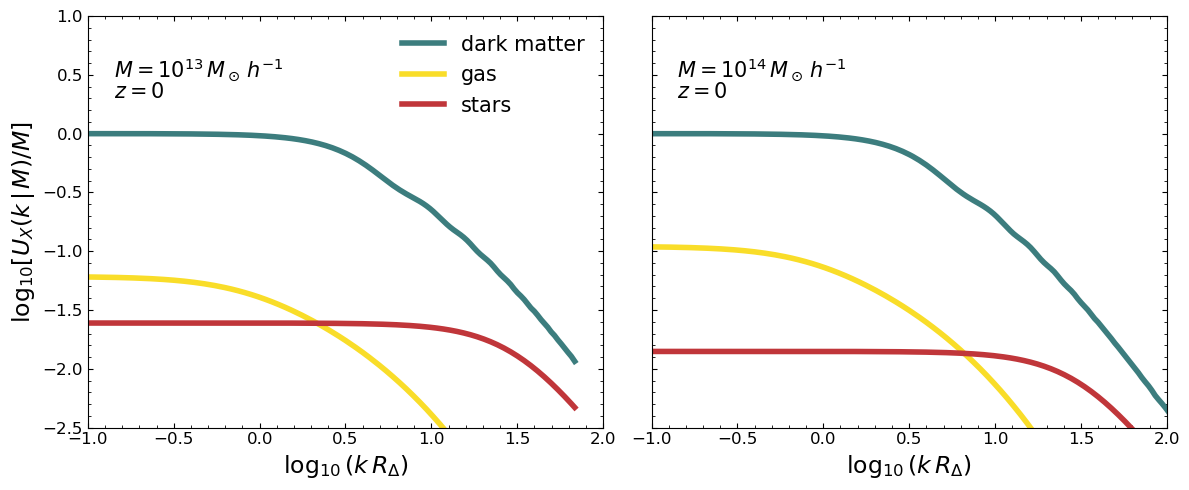

In [4]:
profiles_u = bhm.halo_profiles(a=scale_factor)

# we define the halo masses for which we evaluate the profiles
masses = [1e13, 1e14]  # in Msun/h

labels = ["dark matter", "gas", "stars"]
keys = ["dark_matter", "gas", "stars"]

with plot_style():
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
    cols = get_colors(len(keys))

    for ax, mass in zip(axes, masses):
        radius = bhm.halo_radius(M=mass, a=scale_factor)  # Mpc

        xlog = np.log10(k_grid * radius)

        for key, lab, col in zip(keys, labels, cols):
            y = profiles_u[key](mass, k_grid)  # U_X(k|M)/M
            mask = y > 0
            ylog = np.log10(y[mask])
            ax.plot(xlog[mask], ylog, label=lab, color=col)

        ax.text(
            0.05, 0.85,
            rf"$M = 10^{{{int(np.log10(mass))}}}\,M_\odot\,h^{{-1}}$",
            fontsize=15,
            transform=ax.transAxes,
        )
        ax.text(0.05, 0.8, r"$z = 0$", fontsize=15, transform=ax.transAxes)

        ax.set_xlim(-1, 2)
        ax.set_ylim(-2.5, 1.0)

        ax.set_xlabel(r"$\log_{10}(k\,R_\Delta)$")

    axes[0].set_ylabel(r"$\log_{10}\!\left[U_X(k\,|\,M)/M\right]$")
    axes[0].legend(loc="best", frameon=False)

    # optionally save the figure
    # plt.savefig("halo_profiles.pdf", bbox_inches="tight", dpi=300)

    plt.show()


## Halo radius for the chosen mass definition

Since the profile plots are shown as a function of the dimensionless
variable $kR_\Delta$, we can
visualize the **halo radius** $R_\Delta(M)$ implied by our mass definition (here $\Delta=200$ with
respect to the mean matter density). We plot $R_\Delta$ as a function of halo mass at the chosen
redshift, showing both the **physical** radius and the corresponding **comoving** radius
($R_{\rm comov}=R_{\rm phys}/a$) with respect to the scale factor $a$.

The light gray vertical lines mark the specific halo masses used in the profile panels
(e.g. $10^{13}$ and $10^{14}\,M_\odot/h$), allowing us to read off the associated $R_\Delta$ that enters
the rescaled wavenumber $kR_\Delta$.


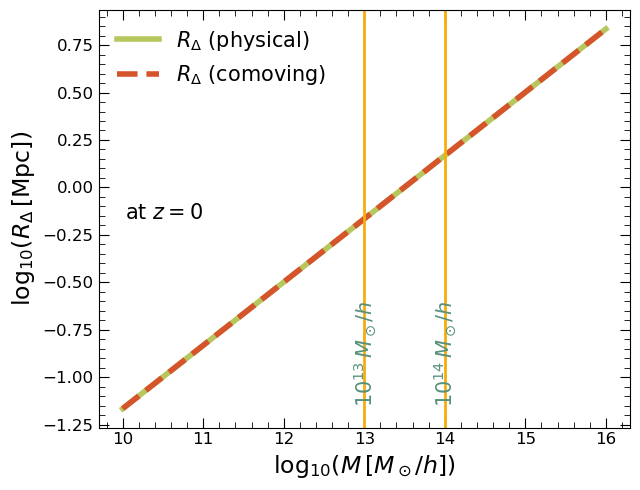

In [5]:
# Halo radius vs mass (for the chosen mass definition)
r_phys = bhm.halo_radius(M=mass_grid, a=scale_factor, frame="physical")  # in Mpc
r_comov = bhm.halo_radius(M=mass_grid, a=scale_factor, frame="comoving")  # in Mpc

with plot_style():
    fig, ax = plt.subplots(figsize=(6.5, 5))

    colors = get_colors(4, cmap_range=(0.3, 0.7))
    ax.plot(np.log10(mass_grid), np.log10(r_phys), color=colors[1],
            label=r"$R_\Delta$ (physical)")
    ax.plot(np.log10(mass_grid), np.log10(r_comov), color=colors[3],
            ls="--", label=r"$R_\Delta$ (comoving)")

    ax.set_xlabel(r"$\log_{10}\!\left(M\,[M_\odot/h]\right)$")
    ax.set_ylabel(r"$\log_{10}\!\left(R_\Delta\,[{\rm Mpc}]\right)$")

    ax.text(0.05, 0.5, r"at $z=0$", transform=ax.transAxes, fontsize=15)

    ax.tick_params(axis="both", which="major", length=7)
    ax.tick_params(axis="both", which="minor", length=4)
    ax.minorticks_on()
    for m in masses:
        x = np.log10(m)
        ax.axvline(x, color=colors[2], lw=2, ls="-",)

        # annotate what the line is
        ax.text(
            x, 0.05,
            rf"$10^{{{int(np.log10(m))}}}\,M_\odot/h$",
            transform=ax.get_xaxis_transform(),  # x in data, y in axes fraction
            ha="center", va="bottom",
            fontsize=15, color=colors[0],
            rotation=90,
        )

    ax.legend(frameon=False, loc="best")

    # optionally save the figure
    # plt.savefig("halo_radius.pdf", bbox_inches="tight", dpi=300)

    plt.show()


# Power spectrum components and baryonic ratios

We now examine the **halo-model power spectra** produced by the Fedeli (2014) baryonic prescription.
The curves shown here are functions of the comoving wavenumber $k$ and correspond to different
contributions to the total matter power spectrum.

We present the results in two complementary ways. First, we show the absolute spectra
$\log_{10} P (k)$ to illustrate how power is distributed across scales and how
individual components contribute to the total signal.
The total power spectrum is obtained as the sum of the individual halo-model
 terms in linear space; this additivity is not visually apparent when displayed in logarithmic units. Second, we show ratios
$\log_{10}\!\left[P(k)/P_{\rm ref}(k)\right]$ relative to a chosen reference spectrum
(e.g. the nonlinear power spectrum of the standard cosmology).
The ratio representation isolates **baryonic effects**, making deviations from the reference
particularly clear on small and intermediate scales where gas and stellar physics are most relevant.

Throughout, all spectra are evaluated on the same $k$ grid and plotted in units of
$h \, \mathrm{Mpc^{-1}}$. A horizontal line at zero in the ratio plots
indicates exact agreement with
the reference model.

These plots corresponds to Figs. 3, 4, 5, and 6 of Fedeli (2014).

Note on the reference spectrum: In Fedeli (2014), Fig. 3 compares the
dark-matter-only halo-model
power spectrum to a version computed with halo concentrations artificially increased by a factor
of two. This is a diagnostic of concentration effects, not a baryon-versus-nonlinear comparison.
In contrast, our ratio plots use a fixed halo-model setup and compare baryonified spectra to a
chosen reference spectrum (by default the nonlinear matter power spectrum). As a result, the
large-$k$ behaviour need not match Fedeli’s Fig. 3. For completeness, this comparison can be reproduced as an exercise by altering the halo concentration–mass relation when constructing the halo-model ingredients via the `CCL` halo and concentration modules.




In [6]:
# We first need to define some plotting functions we can call so we do not
# repeat the same code multiple times later on.
def plot_curves(
    pk_components,
    ys,
    *,
    labels,
    mode="log10",  # "log10" or "log10_ratio"
    denom=None,  # used only for ratio; can be "pk_nlin" or "pk_dmo""
    h=None,
    xlabel=None,
    ylabel=None,
    xlim=None,
    ylim=None,
    figsize=(6, 5),
    legend_loc="best",
    legend_ncol=1,
    frameon=True,
    style_params=None,
    lw=4,
):
    k = np.asarray(pk_components["grid"]["k"], float)
    k = k / float(h)
    unit = r"\mathrm{h\,Mpc^{-1}}"

    x = np.log10(k)
    xlab_default = rf"$\log_{{10}}\!\left(k\,[{unit}]\right)$"

    ys = [np.asarray(y, float) for y in ys]
    labels = list(labels)

    if mode == "log10_ratio":
        if denom is None:
            den = np.asarray(pk_components["pk_ref"]["pk_nlin"], float)
            den_name = "pk_nlin"
        elif isinstance(denom, str):
            # allow denom to live in either pk_ref or pk
            if denom in pk_components.get("pk_ref", {}):
                den = np.asarray(pk_components["pk_ref"][denom], float)
            else:
                den = np.asarray(pk_components["pk"][denom], float)
            den_name = denom

        yplot = [np.log10(y / den) for y in ys]
        if ylabel is None:
            ylabel = rf"$\log_{{10}}\!\left(P/P_{{\rm {den_name}}}\right)$"
    else:
        yplot = [np.log10(y) for y in ys]
        if ylabel is None:
            ylabel = r"$\log_{10}\,P(k)$"

    cols = get_colors(len(ys), cmap="cmr.pride", cmap_range=(0.25, 0.75))

    with plot_style(style_params):
        fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)

        if mode == "log10_ratio":
            ax.axhline(0.0, color="gainsboro", lw=3)
        for i, (lab, y) in enumerate(zip(labels, yplot)):
            ax.plot(x, y, label=lab, lw=lw, color=cols[i])

        ax.set_xlabel(xlab_default if xlabel is None else xlabel)
        ax.set_ylabel(ylabel)
        ax.legend(frameon=frameon, loc=legend_loc, ncol=legend_ncol)

        if xlim is not None:
            ax.set_xlim(*map(float, xlim))
        if ylim is not None:
            ax.set_ylim(*map(float, ylim))

        plt.show()


def plot_spectra(pk_components, ys, *, labels, **kw):
    return plot_curves(pk_components, ys, labels=labels, mode="log10", **kw)


def plot_spectra_ratio(pk_components, ys, *, labels, denom=None, **kw):
    return plot_curves(pk_components, ys, labels=labels, mode="log10_ratio", denom=denom, **kw)


In [7]:
# We use a handy method from BaryonHaloModel called `BaryonHaloModel.pk_components`
# which returns all the relevant power-spectrum components in a dictionary.
# To see the structure of the dictionary simply call .keys() on the returned object.
pk_components = bhm.pk_components(k=k_grid, a=scale_factor)
halo_pairs = pk_components["halo_pairs"]  # individual halo terms dict
pks = pk_components["pk"]  # power spectra dict


## Dark matter power spectra

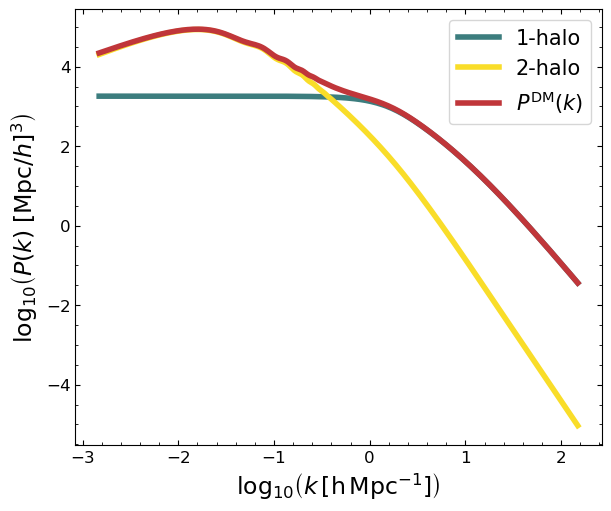

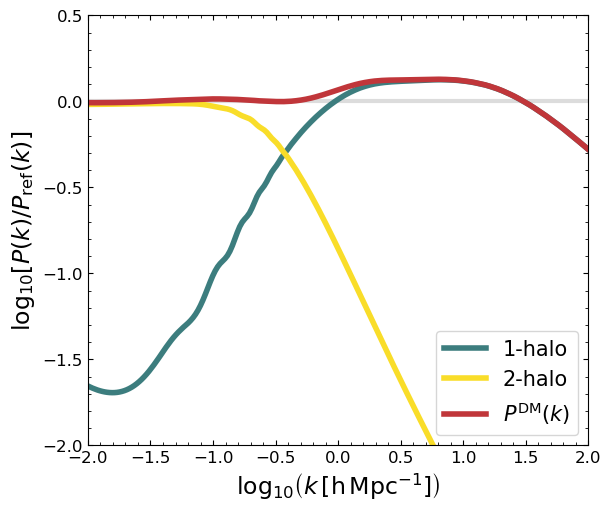

In [8]:
ys = [
    halo_pairs["dm_dm"]["terms"]["1h"],
    halo_pairs["dm_dm"]["terms"]["2h"],
    pks["dm"],
]
labels = [
    r"1-halo",
    r"2-halo",
    r"$P^{\rm DM}(k)$",
]

plot_spectra(
    pk_components,
    ys,
    labels=labels,
    h=cosmo["h"],
    ylabel=r"$\log_{10}\!\left(P(k)\;[\mathrm{Mpc}/h]^3\right)$",
)

plot_spectra_ratio(
    pk_components,
    ys,
    labels=labels,
    h=cosmo["h"],
    xlim=(-2, 2),
    ylim=(-2, 0.5),
    ylabel=r"$\log_{10}\!\left[P(k)/P_{\rm ref}(k)\right]$",
)


## Stellar power spectra

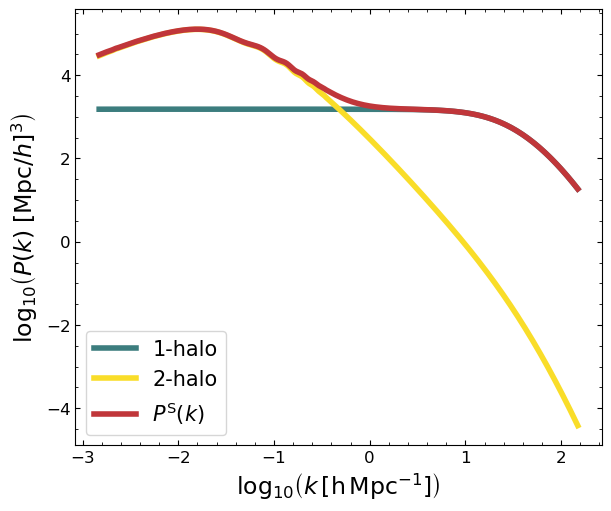

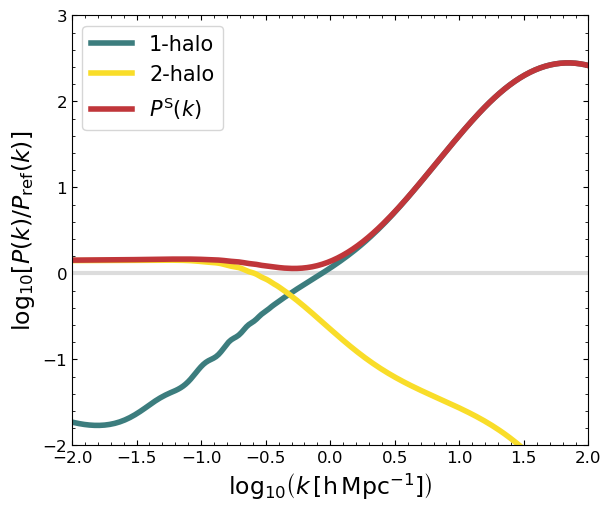

In [9]:
ys = [
    halo_pairs["stars_stars"]["terms"]["1h"],
    halo_pairs["stars_stars"]["terms"]["2h"],
    pks["stars"],  # total P_starstar
]
labels = [
    r"1-halo",
    r"2-halo",
    r"$P^{\rm S}(k)$",
]

plot_spectra(
    pk_components,
    ys,
    labels=labels,
    h=cosmo["h"],
    ylabel=r"$\log_{10}\!\left(P(k)\;[\mathrm{Mpc}/h]^3\right)$",
)

plot_spectra_ratio(
    pk_components,
    ys,
    labels=labels,
    h=cosmo["h"],
    xlim=(-2, 2),
    ylim=(-2, 3),
    ylabel=r"$\log_{10}\!\left[P(k)/P_{\rm ref}(k)\right]$",
)


## Gas power spectra

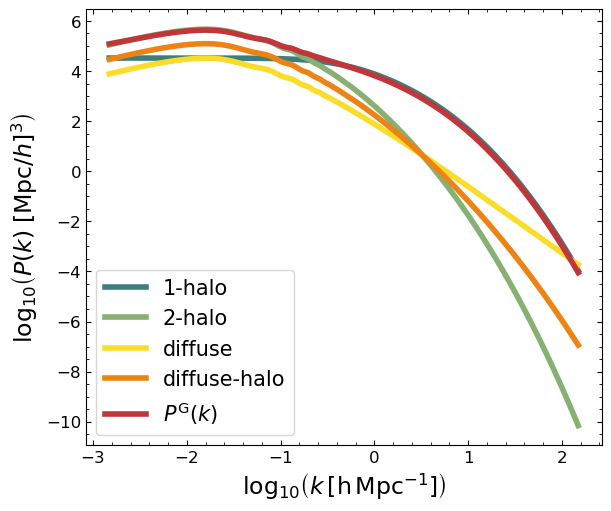

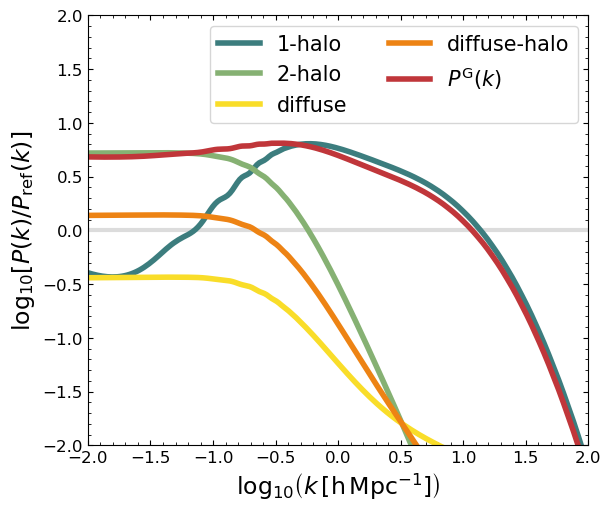

In [10]:
ys = [
    halo_pairs["gas_gas"]["terms"]["1h"],
    halo_pairs["gas_gas"]["terms"]["2h"],
    halo_pairs["gas_gas"]["terms"]["diffuse"],
    halo_pairs["gas_gas"]["terms"]["diffuse_halo"],
    pks["gas"],  # total P_starstar
]
labels = [
    r"1-halo",
    r"2-halo",
    r"diffuse",
    r"diffuse-halo",
    r"$P^{\rm G}(k)$",
]

plot_spectra(
    pk_components,
    ys,
    labels=labels,
    h=cosmo["h"],
    ylabel=r"$\log_{10}\!\left(P(k)\;[\mathrm{Mpc}/h]^3\right)$",
)

plot_spectra_ratio(
    pk_components,
    ys,
    labels=labels,
    h=cosmo["h"],
    xlim=(-2, 2.),
    ylim=(-2, 2),
    ylabel=r"$\log_{10}\!\left[P(k)/P_{\rm ref}(k)\right]$",
    legend_ncol=2,
)


## Dark matter - stars cross-power spectra


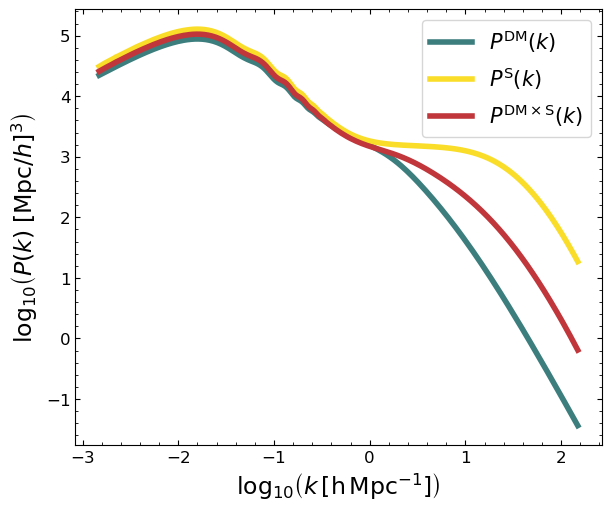

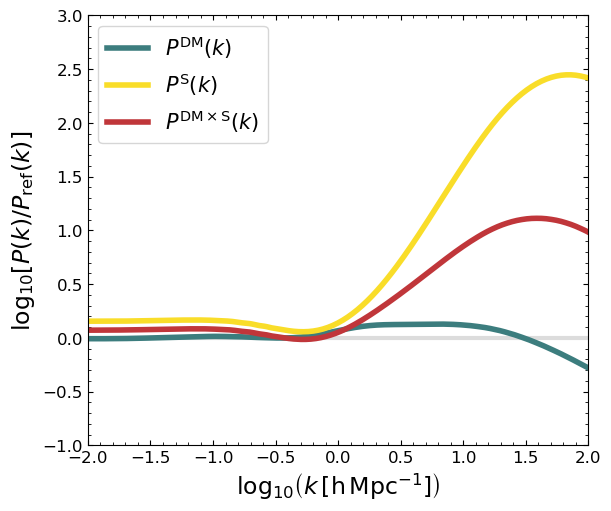

In [11]:
ys = [
    pks["dm"],
    pks["stars"],
    pks["dm_stars"],
]
labels = [
    r"$P^{\rm DM} (k)$",
    r"$P^{\rm S} (k)$",
    r"$P^{\rm DM \times S} (k)$",

]

plot_spectra(
    pk_components,
    ys,
    labels=labels,
    h=cosmo["h"],
    ylabel=r"$\log_{10}\!\left(P(k)\;[\mathrm{Mpc}/h]^3\right)$",
)

plot_spectra_ratio(
    pk_components,
    ys,
    labels=labels,
    h=cosmo["h"],
    xlim=(-2, 2),
    ylim=(-1, 3),
    ylabel=r"$\log_{10}\!\left[P(k)/P_{\rm ref}(k)\right]$",
)


## Dark matter - gas cross-power spectra

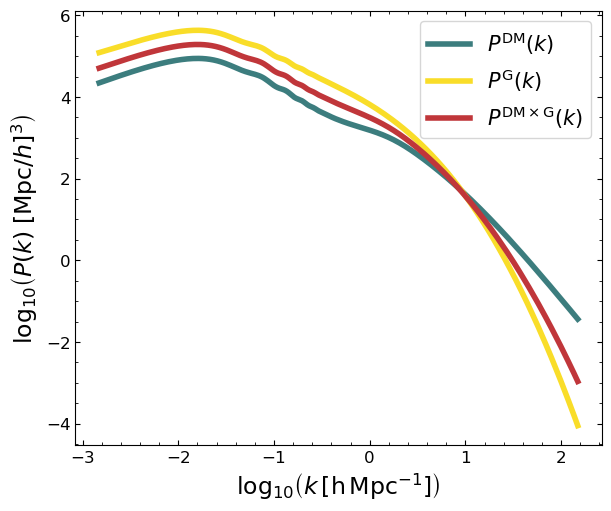

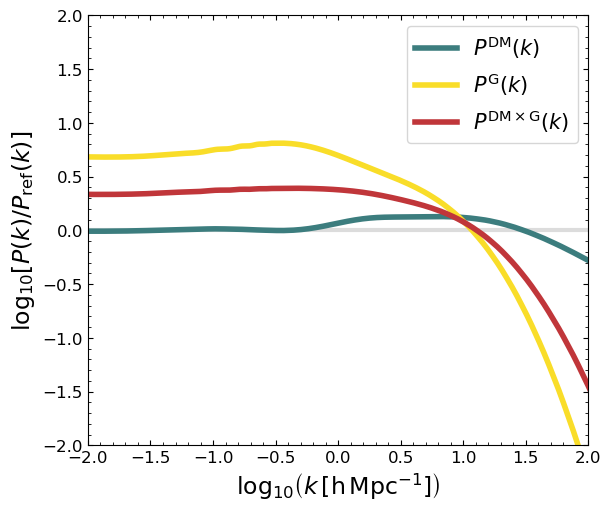

In [12]:
ys = [
    pks["dm"],
    pks["gas"],
    pks["dm_gas"],
]
labels = [
    r"$P^{\rm DM} (k)$",
    r"$P^{\rm G} (k)$",
    r"$P^{\rm DM \times G} (k)$",

]

plot_spectra(
    pk_components,
    ys,
    labels=labels,
    h=cosmo["h"],
    ylabel=r"$\log_{10}\!\left(P(k)\;[\mathrm{Mpc}/h]^3\right)$",
)

plot_spectra_ratio(
    pk_components,
    ys,
    labels=labels,
    h=cosmo["h"],
    xlim=(-2, 2.),
    ylim=(-2, 2),
    ylabel=r"$\log_{10}\!\left[P(k)/P_{\rm ref}(k)\right]$",
)


## Gas - stars cross-power spectra

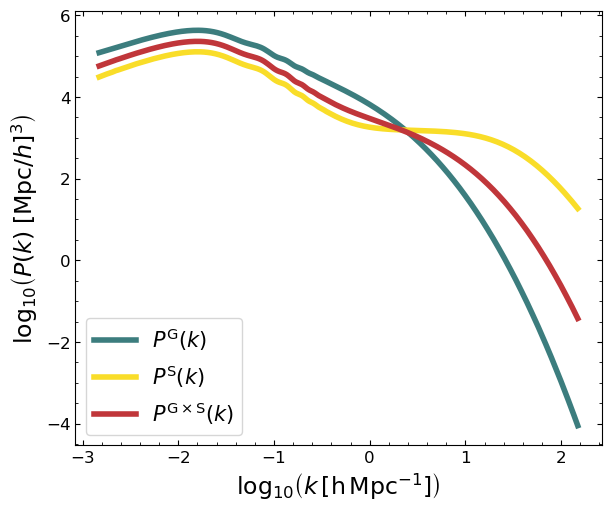

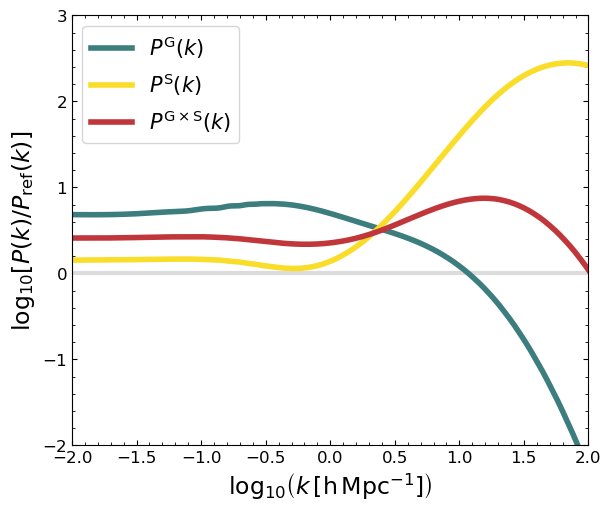

In [13]:
ys = [
    pks["gas"],
    pks["stars"],
    pks["gas_stars"],
]
labels = [
    r"$P^{\rm G} (k)$",
    r"$P^{\rm S} (k)$",
    r"$P^{\rm G \times S} (k)$",

]

plot_spectra(
    pk_components,
    ys,
    labels=labels,
    h=cosmo["h"],
    ylabel=r"$\log_{10}\!\left(P(k)\;[\mathrm{Mpc}/h]^3\right)$",
)

plot_spectra_ratio(
    pk_components,
    ys,
    labels=labels,
    h=cosmo["h"],
    xlim=(-2, 2.),
    ylim=(-2, 3),
    ylabel=r"$\log_{10}\!\left[P(k)/P_{\rm ref}(k)\right]$",
)


## Total matter power spectra

Here the individual curves correspond to the prefactor-weighted halo-model
contributions entering the baryonic power spectrum; the total spectrum $P^{\rm BHM}$
is obtained as the sum of these terms in linear space, even though this additivity is not visually apparent when plotted in logarithmic units.

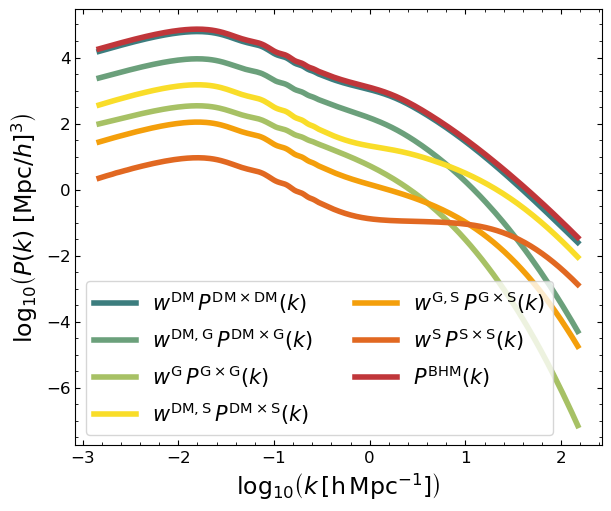

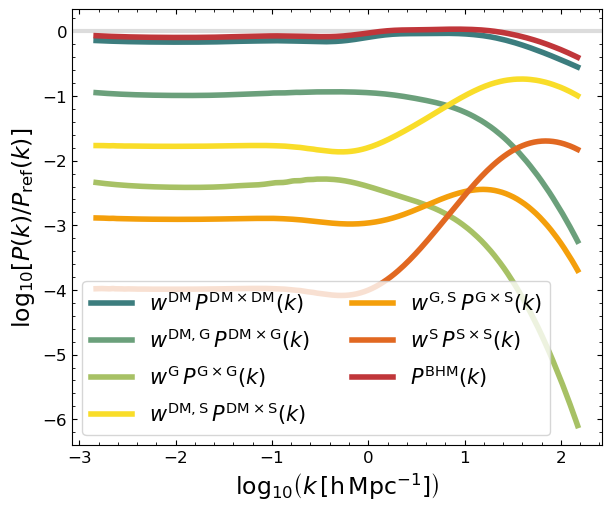

In [14]:
ys = [
    pks["w_dm"],
    pks["w_dm_gas"],
    pks["w_gas"],
    pks["w_dm_stars"],
    pks["w_stars_gas"],
    pks["w_stars"],
    pks["total"],
]

labels = [
    r"$w^{\rm DM}\,P^{\rm DM\times DM} (k)$",
    r"$w^{\rm DM,G}\,P^{\rm DM\times G} (k)$",
    r"$w^{\rm G}\,P^{\rm G\times G} (k)$",
    r"$w^{\rm DM,S}\,P^{\rm DM\times S} (k)$",
    r"$w^{\rm G,S}\,P^{\rm G\times S} (k)$",
    r"$w^{\rm S}\,P^{\rm S\times S} (k)$",
    r"$P^{\rm BHM} (k)$",
]

plot_spectra(
    pk_components,
    ys,
    labels=labels,
    h=cosmo["h"],
    ylabel=r"$\log_{10}\!\left(P(k)\;[\mathrm{Mpc}/h]^3\right)$",
    legend_ncol=2,
)

plot_spectra_ratio(
    pk_components,
    ys,
    labels=labels,
    h=cosmo["h"],
    ylabel=r"$\log_{10}\!\left[P(k)/P_{\rm ref}(k)\right]$",
    legend_ncol=2,
    frameon=True,
)


# One-parameter sensitivity: physical interpretation

To build intuition for which physical ingredients drive the baryonic
correction, we vary **one model parameter at a time** while keeping the rest
 of the halo-model setup fixed (mass definition, mass function, halo bias,
 concentration, and numerical grids). For each variation we compute the
 boost $B (k)$ relative to a dark-matter-only (DMO) halo-model baseline,

$B(k) = \frac{P_{\rm bar}^{\rm HM}(k)}{P_{\rm dmo}^{\rm HM}(k)}$,

and plot the ratio $B(k) / B_{\rm ref}(k)$ with respect to a fiducial baseline
configuration $B_{\rm ref}$.

Technically, this is implemented by rebuilding the halo model with a **single overridden parameter** while reusing all baseline settings. This “override” pattern is used here purely for diagnostic clarity: in practical applications with the `BaryonsFedeli14` class (via the `baryons` module), one would simply **set the desired parameter values directly** when constructing the model. The goal of this exercise is not to prescribe how the model should be configured in an analysis, but to isolate and visualize how each physical parameter impacts the matter power spectrum.

Each panel therefore corresponds to a single physical “knob,” allowing us to assess whether changing that parameter primarily suppresses or enhances power, and on which scales the effect is most pronounced.

#### Mass-fraction parameters

* **$\rho_{\rm S}$** sets the overall normalization of the stellar mass
fraction. Increasing $\rho_{\rm S}$ enhances the contribution of compact stellar components, typically boosting power on small scales where baryons are most centrally concentrated.

* **$m_{0,{\rm S}}$** and **$\sigma_{\rm S}$** control the characteristic
halo
mass scale and width of the stellar mass-fraction transition. Shifting $m_{0,{\rm S}}$ moves the mass range over which stars are most important, while $\sigma_{\rm S}$ controls how sharply this transition occurs.

* **$m_{0,{\rm G}}$** and **$\sigma_{\rm G}$** play an analogous role for
the gas
component, governing the halo masses where gas depletion or redistribution becomes important and how gradually this occurs across the halo population.

#### Gas-profile shape parameters

* **$\beta$** controls the slope of the gas density profile. Larger values
generally produce a steeper fall-off, redistributing gas away from halo centers and suppressing small-scale power.

* **$r_{\rm co}$** sets the core radius of the gas profile, affecting the
inner flattening of the gas distribution.

* **$r_{\rm ej}$** controls the ejection scale of gas due to feedback
processes. Increasing $r_{\rm ej}$ pushes gas to larger radii, leading to
stronger suppression of power on intermediate and small scales.

#### Stellar-profile parameters

* **$x_\Delta$** sets the characteristic stellar scale relative to the halo
overdensity radius. Varying this parameter changes how concentrated the stellar component is within halos.

* **$\alpha$** controls the inner slope of the stellar profile, primarily
affecting the smallest scales.

#### Diffuse gas mixing parameters

* **$F_{\rm G}$** regulates the fraction of gas retained in halos versus mixed
into
a diffuse component. Values closer to unity correspond to minimal gas ejection, while smaller values increase large-scale redistribution and suppress clustering power.

* **$b_{\rm d}$** parametrizes the bias of the diffuse gas component relative
 to
the matter distribution, modulating how efficiently redistributed gas contributes back to large-scale power.

Overall, these one-parameter sweeps provide a controlled way to understand
**which physical mechanisms are responsible for suppressing or enhancing the
 matter power spectrum, and on which scales**. This intuition is essential when interpreting baryonic uncertainties in cosmological analyses, even though realistic applications will vary multiple parameters simultaneously.


In [15]:
# Sensitivity grid: B(k)/B_ref(k)
bhm0 = bhm
boost_ref = bhm0.boost(k=k_grid, a=scale_factor, pk_ref="pk_dmo")
x = np.log10(k_grid)  # k in 1/Mpc

def _make_bhm_with(**overrides):
    """Rebuild BaryonHaloModel with baseline settings, overriding selected params."""
    # baseline params pulled from bhm0 internals
    base_frac = bhm0._mass_frac_params
    base_gas = bhm0._gas_profile_params
    base_star = bhm0._star_profile_params

    return BaryonHaloModel(
        cosmo=cosmo,
        mass_def=mass_def,
        mass_function=hmf,
        halo_bias=getattr(bhm0, "halo_bias", None),
        concentration=getattr(bhm0, "concentration", None),

        # MASS FRACTIONS
        rho_star=overrides.get("rho_star", base_frac.get("rho_star", None)),
        m0_star=overrides.get("m0_star", base_frac["m0_star"]),
        sigma_star=overrides.get("sigma_star", base_frac["sigma_star"]),
        m0_gas=overrides.get("m0_gas", base_frac["m0_gas"]),
        sigma_gas=overrides.get("sigma_gas", base_frac["sigma_gas"]),

        # PROFILE SHAPES
        gas_beta=overrides.get("gas_beta", base_gas["beta"]),
        gas_r_co=overrides.get("gas_r_co", base_gas["r_co"]),
        gas_r_ej=overrides.get("gas_r_ej", base_gas["r_ej"]),
        star_x_delta=overrides.get("star_x_delta", base_star["x_delta"]),
        star_alpha=overrides.get("star_alpha", base_star["alpha"]),

        # DIFFUSE GAS MIXING
        Fg=overrides.get("Fg", bhm0.Fg),
        bd=overrides.get("bd", bhm0.bd),
    )

def tex_sci(v: float, *, sig: int = 2) -> str:
    """Return v as TeX scientific notation, e.g. 1.2×10^{-13}."""
    if v == 0:
        return "0"
    m, e = f"{v:.{sig}e}".split("e")
    return rf"{m}\times10^{{{int(e)}}}"

# We need to define rho_star_base here, since
# it gets cached in bhm0._mass_frac_params
rho_star_base = bhm0._mass_frac_params.get("rho_star")
if rho_star_base is None:
    rho_star_base = 7.0e8 * float(cosmo["h"])**2

panels = [
    (r"Mass fractions: $\rho_{\rm S}$", "rho_star",
     [rho_star_base * f for f in [0.25, 0.35, 0.50, 0.70, 1.00, 1.40, 2.00, 2.80, 4.00]],
     lambda v: rf"$\rho_{{\rm S}}={tex_sci(v, sig=1)}$"),

    (r"Mass fractions: $m_{0,{\rm S}}$", "m0_star",
     [5.0e12 * f for f in [0.25, 0.35, 0.50, 0.70, 1.00, 1.40, 2.00, 2.80, 4.00]],
     lambda v: rf"$m_{{0,\rm S}}={tex_sci(v, sig=1)}$"),

    (r"Mass fractions: $\sigma_{{\rm S}}$", "sigma_star",
     [1.2 + d for d in [-0.6, -0.45, -0.30, -0.15, 0.0, 0.15, 0.30, 0.45, 0.60]],
     lambda v: rf"$\sigma_{{\rm S}}={v:.2f}$"),

    (r"Mass fractions: $m_{0,{\rm G}}$", "m0_gas",
     [1.0e12 * f for f in [0.25, 0.35, 0.50, 0.70, 1.00, 1.40, 2.00, 2.80, 4.00]],
     lambda v: rf"$m_{{0,\rm S}}={tex_sci(v, sig=1)}$"),

    (r"Mass fractions: $\sigma_{{\rm G}}$", "sigma_gas",
     [3.0 + d for d in [-1.5, -1.125, -0.75, -0.375, 0.0, 0.375, 0.75, 1.125, 1.5]],
     lambda v: rf"$\sigma_{{\rm F}}={v:.2f}$"),

    (r"Gas profile: $\beta$", "gas_beta",
     [2.9 + d for d in [-0.9, -0.675, -0.45, -0.225, 0.0, 0.225, 0.45, 0.675, 0.9]],
     lambda v: rf"$\beta={v:.2f}$"),

    (r"Gas profile: $r_{\rm co}$", "gas_r_co",
     [0.1 * f for f in [0.25, 0.35, 0.50, 0.70, 1.00, 1.40, 2.00, 2.80, 4.00]],
     lambda v: rf"$r_{{\rm co}}={v:.3f}$"),

    (r"Gas profile: $r_{\rm ej}$", "gas_r_ej",
     [4.5 * f for f in [0.25, 0.35, 0.50, 0.70, 1.00, 1.40, 2.00, 2.80, 4.00]],
     lambda v: rf"$r_{{\rm ej}}={v:.2f}$"),

    (r"Stellar profile: $x_\Delta$", "star_x_delta",
     [(1.0/0.03) * f for f in [0.25, 0.35, 0.50, 0.70, 1.00, 1.40, 2.00, 2.80, 4.00]],
     lambda v: rf"$x_\Delta={v:.1f}$"),

    (r"Stellar profile: $\alpha$", "star_alpha",
     [1.0 + d for d in [-0.4, -0.3, -0.2, -0.1, 0.0, 0.1, 0.2, 0.3, 0.4,]],
     lambda v: rf"$\alpha={v:.2f}$"),

    # Fg must be in [0, 1] -> symmetric around 0.9 but clipped manually
    (r"Diffuse mixing: $F_{\rm G}$", "Fg",
     [0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.975, 0.99, 1.00],
     lambda v: rf"$F_{{\rm G}}={v:.2f}$"),

    (r"Diffuse mixing: $b_{\rm d}$", "bd",
     [0.6 + d for d in [-0.45, -0.3375, -0.225, -0.1125, 0.0, 0.1125, 0.225, 0.3375, 0.45]],
     lambda v: rf"$b_{{\rm d}}={v:.2f}$"),
]


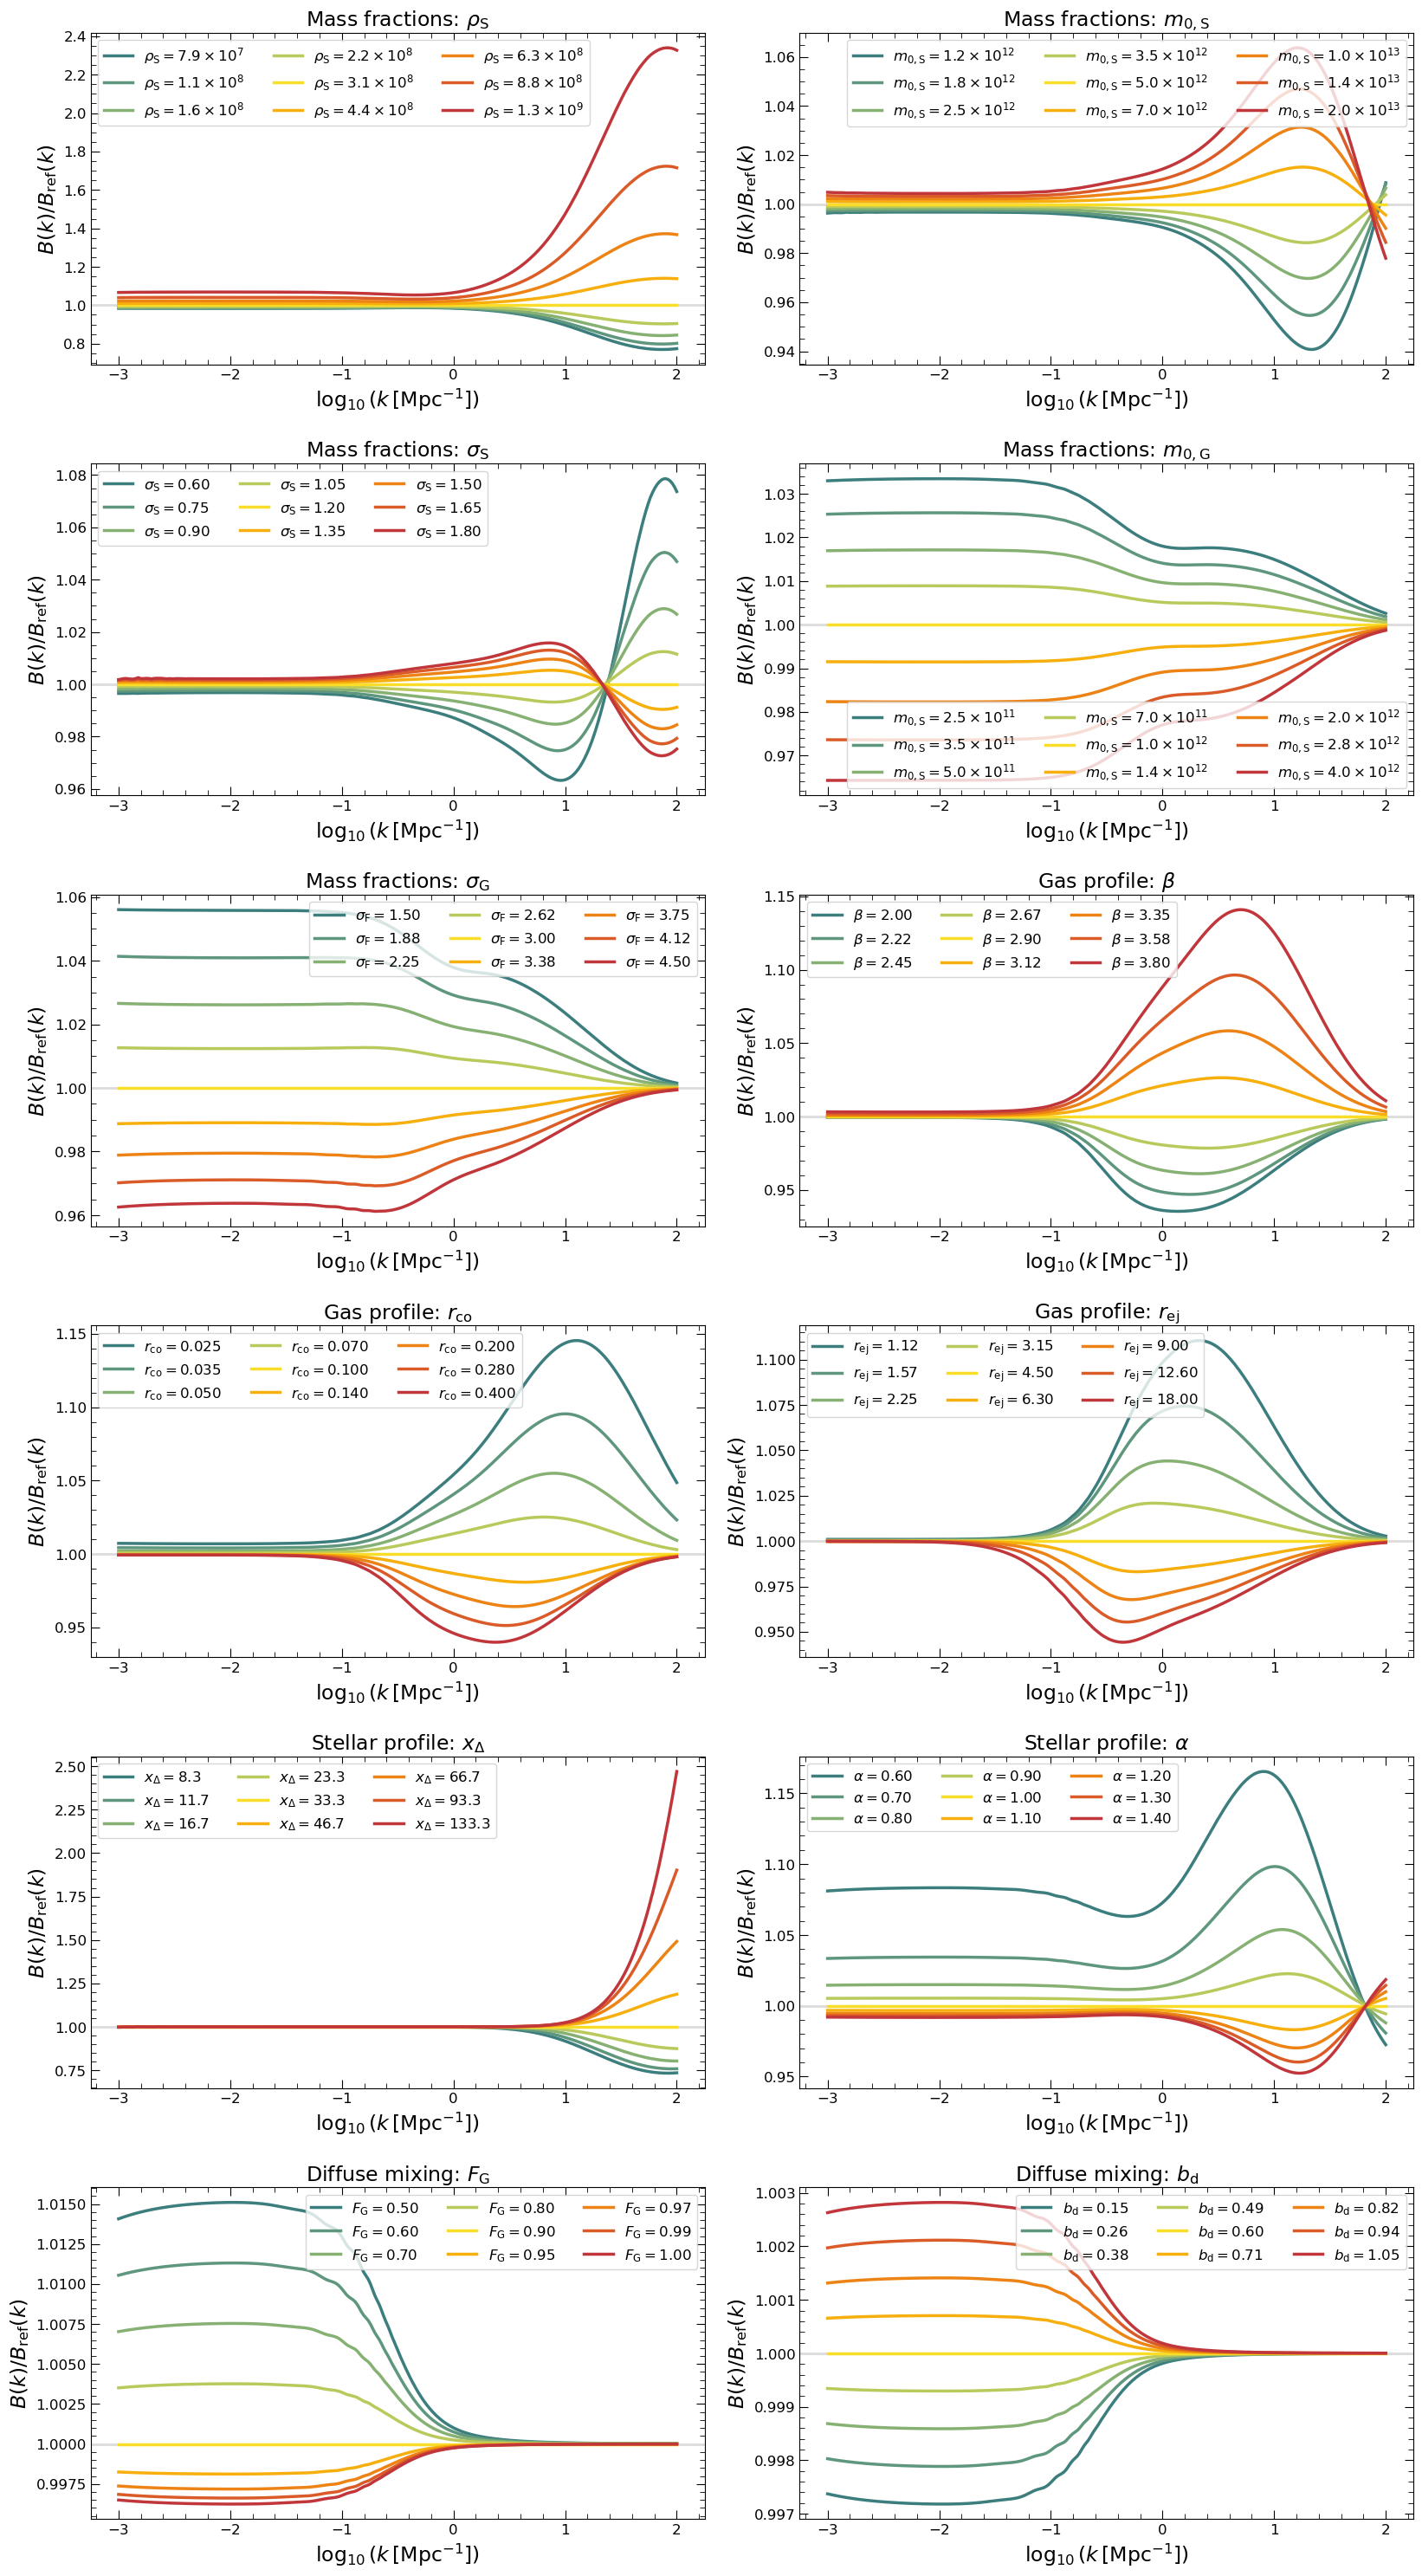

In [16]:
with plot_style():
    ncols = 2
    nrows = int(np.ceil(len(panels) / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(17, 5 * nrows),
        #constrained_layout=True,
    )
    fig.subplots_adjust(wspace=0.25, hspace=6)

    # axes is 2D if nrows>1, but could be 1D if nrows==1
    axes = np.atleast_1d(axes).ravel()

    for ax, (title, key, vals, labfmt) in zip(axes, panels):
        cols = get_colors(len(vals))

        ax.axhline(1.0, c="gainsboro", lw=2)

        for v, col in zip(vals, cols):
            bhm_i = _make_bhm_with(**{key: v})
            boost_i = bhm_i.boost(k=k_grid, a=scale_factor, pk_ref="pk_dmo")
            ax.plot(x, boost_i / boost_ref, lw=2.5, color=col, label=labfmt(v))

        ax.set_title(title, fontsize=17)
        ax.set_xlabel(r"$\log_{10}(k\,[{\rm Mpc}^{-1}])$")
        ax.set_ylabel(r"$B(k)/B_{\rm ref}(k)$")
        ax.tick_params(axis="both", which="major", length=7)
        ax.tick_params(axis="both", which="minor", length=4)
        ax.minorticks_on()
        ax.legend(frameon=True, loc="best", fontsize=12, ncols=3)

    # hide any unused axes (since nrows*ncols may exceed len(panels))
    for ax in axes[len(panels):]:
        ax.set_visible(False)

    # optionally save the figure
    # plt.savefig("bhm_oneparam_sensitivity.pdf", bbox_inches="tight", dpi=300)

    plt.show()